In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
WINDOW_SIZE = 30
EPOCHS = 25
LEARNING_RATE = 0.0005
BATCH_SIZE = 64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
import numpy as np

X_train = np.load("processed_data/X_train.npy")
y_train = np.load("processed_data/y_train.npy")

print(X_train.shape)
print(y_train.shape)

(17731, 30, 16)
(17731,)


In [4]:
X_train_tf, X_val_tf, y_train_tf, y_val_tf = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

In [5]:
class RULDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [6]:
train_dataset = RULDataset(X_train_tf, y_train_tf)
val_dataset = RULDataset(X_val_tf, y_val_tf)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [7]:
import torch.nn as nn
class TransformerRULModel(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super(TransformerRULModel, self).__init__()

        self.input_projection = nn.Linear(input_size, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.fc = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.input_projection(x)
        x = self.transformer_encoder(x)
        x = x[:, -1, :]
        output = self.fc(x)
        return output.squeeze()

In [8]:
def get_health_status(rul):
    if rul > 80:
        return "Healthy"
    elif rul > 40:
        return "Warning"
    else:
        return "Critical"

In [10]:
input_size = X_train.shape[2]

model = TransformerRULModel(
    input_size=input_size,
    d_model=32,
    nhead=4,
    num_layers=1,
    dropout=0.4
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

In [11]:
train_losses = []
val_losses = []

best_val_loss = float("inf")
patience = 5
patience_counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}], "
        f"Train Loss: {avg_train_loss:.4f}, "
        f"Val Loss: {avg_val_loss:.4f}"
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "models/best_transformer_rul_model.pth")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

Epoch [1/25], Train Loss: 6323.5055, Val Loss: 3173.0630
Epoch [2/25], Train Loss: 1347.6367, Val Loss: 498.1828
Epoch [3/25], Train Loss: 601.8071, Val Loss: 371.7147
Epoch [4/25], Train Loss: 566.9401, Val Loss: 364.2892
Epoch [5/25], Train Loss: 543.5928, Val Loss: 342.9671
Epoch [6/25], Train Loss: 533.5569, Val Loss: 348.4526
Epoch [7/25], Train Loss: 516.2876, Val Loss: 334.8103
Epoch [8/25], Train Loss: 516.3876, Val Loss: 333.2810
Epoch [9/25], Train Loss: 517.9001, Val Loss: 334.9585
Epoch [10/25], Train Loss: 489.9005, Val Loss: 302.8173
Epoch [11/25], Train Loss: 473.1034, Val Loss: 305.8169
Epoch [12/25], Train Loss: 463.8948, Val Loss: 297.7726
Epoch [13/25], Train Loss: 456.4030, Val Loss: 309.9389
Epoch [14/25], Train Loss: 445.0266, Val Loss: 372.1688
Epoch [15/25], Train Loss: 447.3051, Val Loss: 312.7722
Epoch [16/25], Train Loss: 423.5101, Val Loss: 330.0397
Epoch [17/25], Train Loss: 417.0970, Val Loss: 273.0740
Epoch [18/25], Train Loss: 411.2435, Val Loss: 294.043

In [12]:
model.load_state_dict(torch.load("models/best_transformer_rul_model.pth"))
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        all_preds.extend(outputs.cpu().numpy())
        all_targets.extend(y_batch.numpy())

transformer_mae = mean_absolute_error(all_targets, all_preds)
transformer_mse = mean_squared_error(all_targets, all_preds)
transformer_rmse = np.sqrt(transformer_mse)
transformer_r2 = r2_score(all_targets, all_preds)

print("Transformer MAE:", transformer_mae)
print("Transformer MSE:", transformer_mse)
print("Transformer RMSE:", transformer_rmse)
print("Transformer R2:", transformer_r2)

Transformer MAE: 11.713368170961111
Transformer MSE: 246.9575281083075
Transformer RMSE: 15.714882376534273
Transformer R2: 0.8574950920794666


In [13]:
print(X_train_tf.shape)
print(X_val_tf.shape)

print(len(train_dataset))
print(len(val_dataset))

(14184, 30, 16)
(3547, 30, 16)
14184
3547


In [14]:
print(X_train_tf.shape)
print(X_val_tf.shape)

print("Train and validation are different sizes, so they are separate.")

(14184, 30, 16)
(3547, 30, 16)
Train and validation are different sizes, so they are separate.


In [15]:
print(np.unique(y_train_tf[:10]))
print(np.unique(y_val_tf[:10]))

[ 10  11  14  29  53  73 103 111 125]
[ 21  39  40  76  78  88 125]


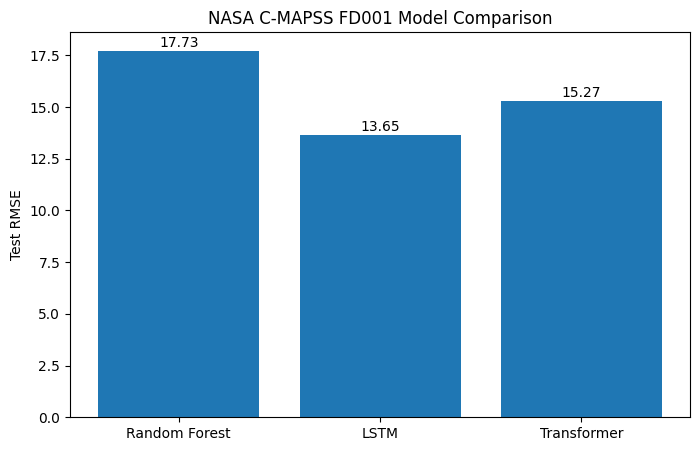

In [2]:
import matplotlib.pyplot as plt
import os

os.makedirs("results", exist_ok=True)

models = [
    "Random Forest",
    "LSTM",
    "Transformer"
]

rmse_values = [
    17.73,
    13.65,
    15.27
]

plt.figure(figsize=(8,5))
plt.bar(models, rmse_values)

plt.ylabel("Test RMSE")
plt.title("NASA C-MAPSS FD001 Model Comparison")

for i, value in enumerate(rmse_values):
    plt.text(i, value + 0.2, f"{value:.2f}", ha="center")

plt.savefig(
    "results/transformer/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

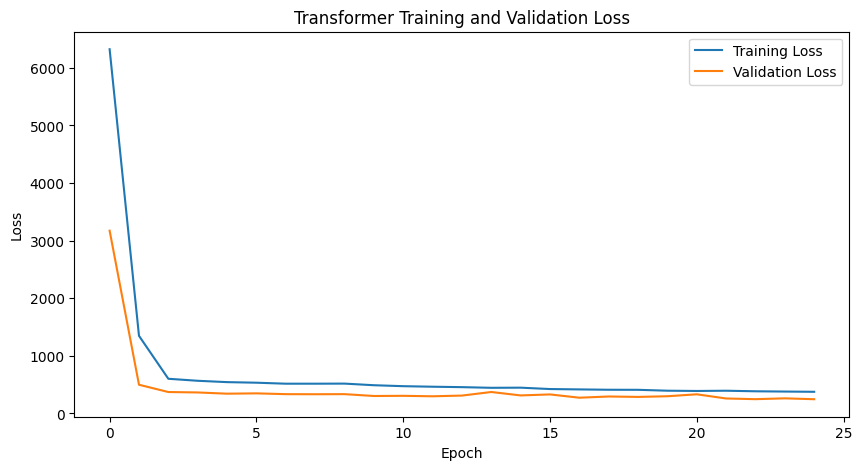

In [30]:
os.makedirs("results/transformer", exist_ok=True)

plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transformer Training and Validation Loss")
plt.legend()
plt.savefig("results/transformer/transformer_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

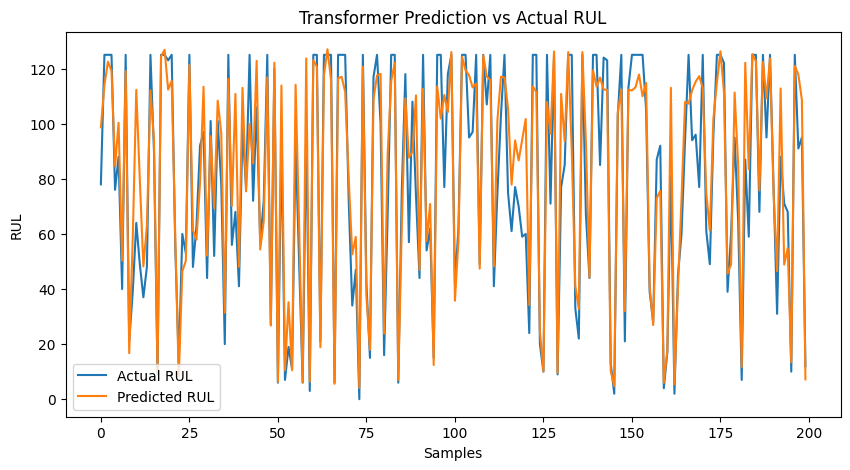

In [31]:
plt.figure(figsize=(10,5))
plt.plot(all_targets[:200], label="Actual RUL")
plt.plot(all_preds[:200], label="Predicted RUL")
plt.xlabel("Samples")
plt.ylabel("RUL")
plt.title("Transformer Prediction vs Actual RUL")
plt.legend()
plt.savefig("results/transformer/transformer_prediction_vs_actual.png", dpi=300, bbox_inches="tight")
plt.show()

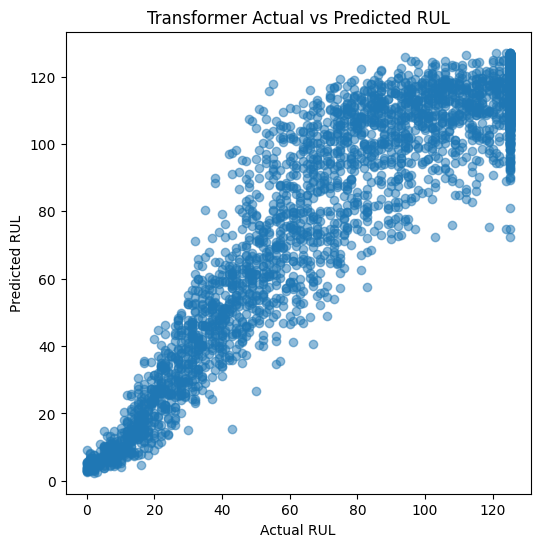

In [32]:
plt.figure(figsize=(6,6))
plt.scatter(all_targets, all_preds, alpha=0.5)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Transformer Actual vs Predicted RUL")
plt.savefig("results/transformer/transformer_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
os.makedirs("models", exist_ok=True)

torch.save(model.state_dict(), "models/best_transformer_rul_model.pth")
print("Transformer model saved successfully.")

Transformer model saved successfully.


In [17]:
import pandas as pd

columns = [
    "engine_id","cycle",
    "setting_1","setting_2","setting_3",
    "sensor_1","sensor_2","sensor_3","sensor_4","sensor_5",
    "sensor_6","sensor_7","sensor_8","sensor_9","sensor_10",
    "sensor_11","sensor_12","sensor_13","sensor_14","sensor_15",
    "sensor_16","sensor_17","sensor_18","sensor_19","sensor_20",
    "sensor_21"
]

test_df = pd.read_csv(
    "data/test_FD001.txt",
    sep=r"\s+",
    header=None
)

test_df.columns = columns

In [18]:
true_rul = pd.read_csv(
    "data/RUL_FD001.txt",
    sep=r"\s+",
    header=None
)

true_rul.columns = ["RUL"]

In [19]:
import joblib

scaler = joblib.load("models/scaler.pkl")

In [20]:
drop_cols = [
    "setting_3",
    "sensor_1",
    "sensor_5",
    "sensor_6",
    "sensor_10",
    "sensor_16",
    "sensor_18",
    "sensor_19"
]

test_df = test_df.drop(columns=drop_cols, errors="ignore")

In [21]:
feature_cols = list(scaler.feature_names_in_)

In [22]:
test_df[feature_cols] = scaler.transform(
    test_df[feature_cols]
)

In [23]:
def create_test_sequences(
    test_df,
    feature_cols,
    window_size=30
):

    X_test = []

    for engine_id in test_df["engine_id"].unique():

        engine_data = test_df[
            test_df["engine_id"] == engine_id
        ].reset_index(drop=True)

        features = engine_data[
            feature_cols
        ].values

        if len(features) >= window_size:

            X_test.append(
                features[-window_size:]
            )

        else:

            pad_size = (
                window_size -
                len(features)
            )

            padding = np.zeros(
                (
                    pad_size,
                    features.shape[1]
                )
            )

            padded_sequence = np.vstack(
                (
                    padding,
                    features
                )
            )

            X_test.append(
                padded_sequence
            )

    return np.array(X_test)

In [24]:
WINDOW_SIZE = 30
RUL_CAP = 125

X_test = create_test_sequences(
    test_df,
    feature_cols,
    WINDOW_SIZE
)

y_test = true_rul["RUL"].clip(
    upper=RUL_CAP
).values

print(X_test.shape)
print(y_test.shape)

(100, 30, 16)
(100,)


In [25]:
test_dataset = RULDataset(
    X_test,
    y_test
)

In [26]:
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [27]:
model.eval()

test_preds = []
test_targets = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        test_preds.extend(
            outputs.cpu().numpy()
        )

        test_targets.extend(
            y_batch.numpy()
        )

In [28]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

test_mae = mean_absolute_error(
    test_targets,
    test_preds
)

test_rmse = np.sqrt(
    mean_squared_error(
        test_targets,
        test_preds
    )
)

test_r2 = r2_score(
    test_targets,
    test_preds
)

print("Transformer Test MAE:", test_mae)
print("Transformer Test RMSE:", test_rmse)
print("Transformer Test R2:", test_r2)

Transformer Test MAE: 11.253607592582703
Transformer Test RMSE: 15.266366810888483
Transformer Test R2: 0.854868502161855
